# Load and Verify the Research Split

In [1]:

import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader 

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score


In [2]:

# Select GPU if available, otherwise use CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [3]:


DATA_ROOT = Path("/kaggle/input/datasets/francismon/curated-covid19-chest-xray-dataset/dataset")

SPLIT_FILE = Path("/kaggle/input/datasets/jamiulkawsar/curated-covid-chest-x-ray-csv-dataset/data_split.csv")

split_df = pd.read_csv(SPLIT_FILE)

print("Total images:", len(split_df))
print("\nColumns:")
print(split_df.columns.tolist())

print("\nFirst 5 rows:")
display(split_df.head())

Total images: 9208

Columns:
['path', 'label', 'class', 'split']

First 5 rows:


,path,label,class,split
0,train/2_Pneumonia/Pneumonia-Bacterial (1153).jpg,2,2_Pneumonia,train
1,train/0_Normal/Normal (1926).jpg,0,0_Normal,train
2,train/2_Pneumonia/Pneumonia-Viral (364).jpg,2,2_Pneumonia,train
3,train/2_Pneumonia/Pneumonia-Bacterial (973).jpg,2,2_Pneumonia,train
4,train/2_Pneumonia/Pneumonia-Bacterial (280).jpg,2,2_Pneumonia,train


In [4]:
sample_path = DATA_ROOT / split_df.iloc[0]["path"]

print("Sample image path:")
print(sample_path)

print("\nExists:", sample_path.exists())

Sample image path:
/kaggle/input/datasets/francismon/curated-covid19-chest-xray-dataset/dataset/train/2_Pneumonia/Pneumonia-Bacterial (1153).jpg

Exists: True


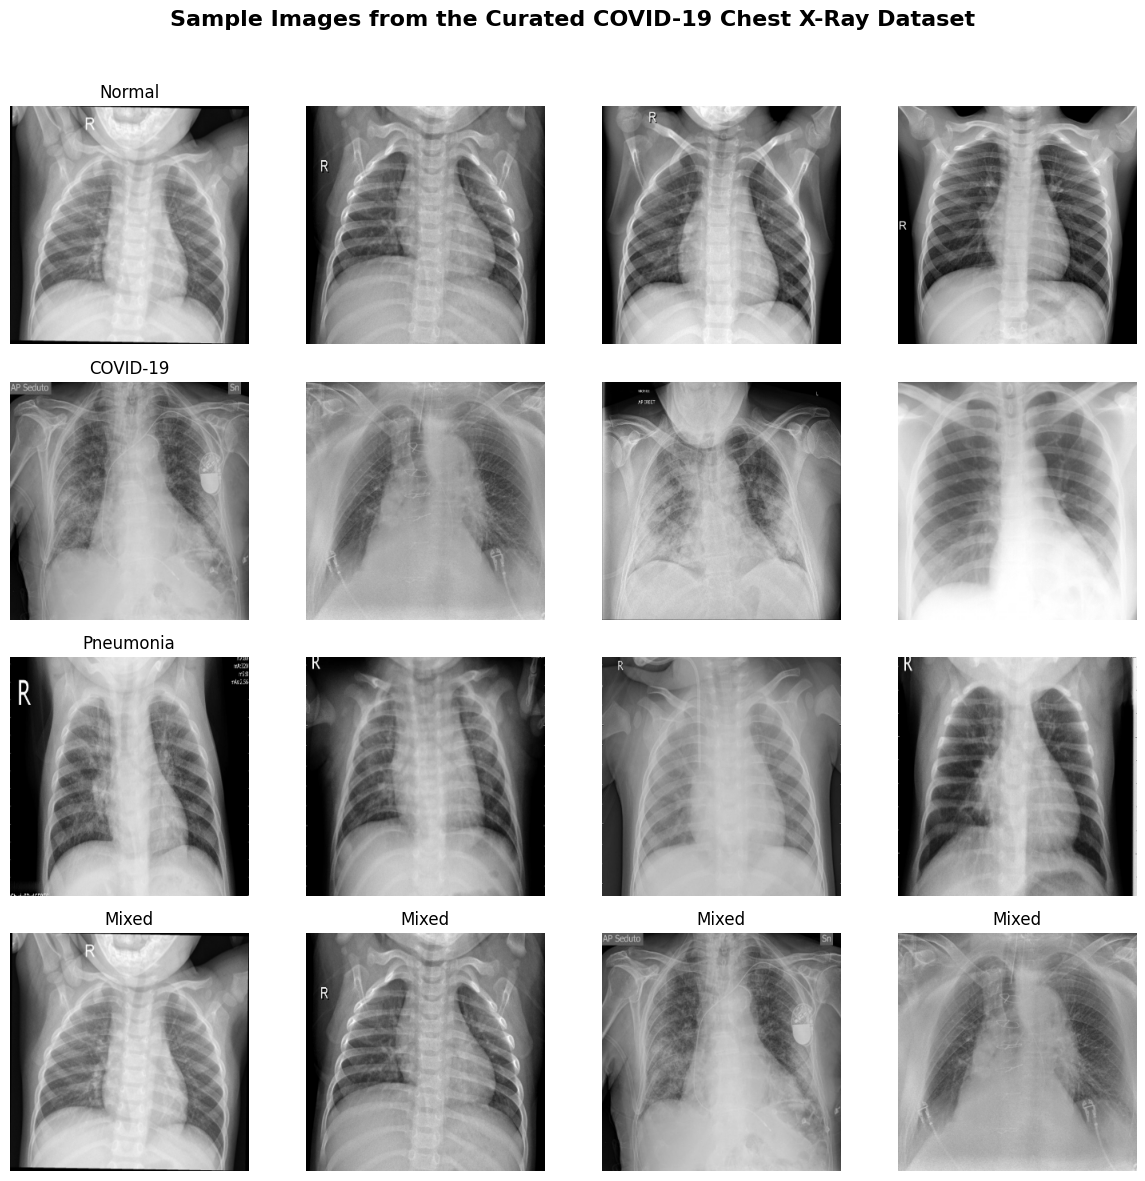

In [5]:

classes = {
    "Normal": "0_Normal",
    "COVID-19": "1_Covid19",
    "Pneumonia": "2_Pneumonia"
}

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Main title
fig.suptitle(
    "Sample Images from the Curated COVID-19 Chest X-Ray Dataset",
    fontsize=16,
    fontweight="bold"
)

# First 3 rows: 4 images from each class
for row, (class_name, folder_name) in enumerate(classes.items()):
    image_paths = list(DATA_ROOT.rglob(f"{folder_name}/*.jpg"))[:4]

    for col, image_path in enumerate(image_paths):

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name, fontsize=12)

# Fourth row: mixed images from all 3 classes
mixed_images = []

for folder_name in classes.values():
    mixed_images.extend(list(DATA_ROOT.rglob(f"{folder_name}/*.jpg"))[:2])

for col, image_path in enumerate(mixed_images[:4]):

    image = Image.open(image_path)

    axes[3, col].imshow(image)
    axes[3, col].axis("off")
    axes[3, col].set_title("Mixed", fontsize=12)

# Leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# PyTorch Dataset Pipeline

In [6]:
# create the pytorch dataset

class ChestXRayDataset(Dataset):

  def __init__(self, dataframe, data_root, transform = None):
    self.dataframe = dataframe.reset_index(drop = True)
    self.data_root = Path(data_root)
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    row = self.dataframe.iloc[index]

    image_path = self.data_root / row["path"]
    label = int(row["label"])

    image = Image.open(image_path).convert("RGB")
    if self.transform:
      image = self.transform(image)

    return image, label


In [7]:
# craete the three obj
train_data = split_df[split_df["split"] == "train"]
val_data = split_df[split_df["split"] == "validation"]
test_data = split_df[split_df["split"] == "test"]

train_dataset = ChestXRayDataset(train_data, DATA_ROOT)
val_dataset = ChestXRayDataset(val_data, DATA_ROOT)
test_dataset = ChestXRayDataset(test_data, DATA_ROOT)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 6445
Validation: 1381
Test: 1382


In [8]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Label:", label)

Image type: <class 'PIL.Image.Image'>
Image size: (299, 299)
Label: 2


 # Image Preprocessing & Data Augmentation

In [9]:
#Create the transform definitions

IMAGE_SIZE = 224
IMAGE_MEAN = [0.485, 0.456, 0.406]
IMAGE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(degrees = 10),
    transforms.ToTensor(),
    transforms.Normalize(mean = IMAGE_MEAN, std = IMAGE_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = IMAGE_MEAN, std = IMAGE_STD)
])

In [10]:
#Recreate the datasets
train_dataset = ChestXRayDataset(
    train_data,
    DATA_ROOT,
    transform = train_transform
)

val_dataset = ChestXRayDataset(
    val_data,
    DATA_ROOT,
    transform = val_test_transform
)

test_dataset = ChestXRayDataset(
    test_data,
    DATA_ROOT,
    transform = val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
#

Train: 6445
Validation: 1381
Test: 1382


In [11]:
#Test one sample
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Image dtype: torch.float32
Label: 2


# PyTorch DataLoaders

In [12]:
# Create DataLoaders

BATCH_SIZE = 32


#train loader
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 2
)

# validation loader
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2
)

# test loader
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 2
)

In [13]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 0, 2, 2, 2, 2, 0, 2,
        2, 1, 2, 2, 1, 2, 0, 2])
Image dtype: torch.float32
Label dtype: torch.int64


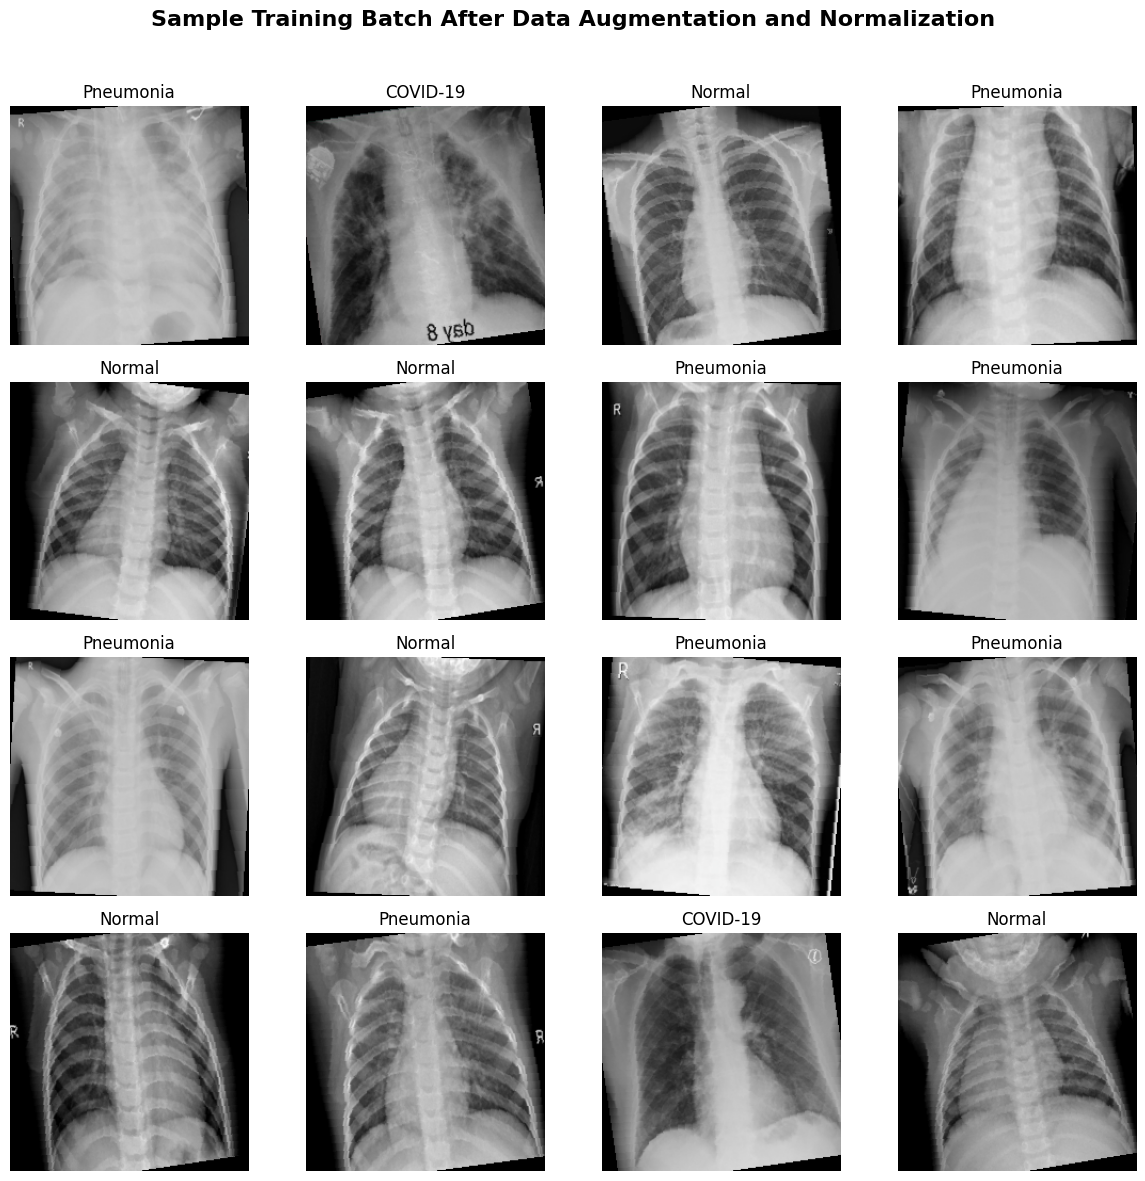

In [14]:

# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

# ImageNet normalization values
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Create 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Main title
fig.suptitle(
    "Sample Training Batch After Data Augmentation and Normalization",
    fontsize=16,
    fontweight="bold"
)

for i, ax in enumerate(axes.flat):

    image = images[i]

    # Undo normalization for visualization
    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    # [C, H, W] → [H, W, C]
    image = image.permute(1, 2, 0)

    # Display image
    ax.imshow(image)
    ax.axis("off")

    # Class name
    class_names = ["Normal", "COVID-19", "Pneumonia"]
    ax.set_title(class_names[labels[i].item()])

# Leave space for the main title
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Resnet50 Frozen

In [15]:
# =========================
# Experiment Configuration
# =========================

SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32

NUM_CLASSES = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

CLASS_NAMES = [
    "Normal",
    "COVID-19",
    "Pneumonia"
]

MODEL_NAME = "CustomCNN"

print("Model:", MODEL_NAME)
print("Number of classes:", NUM_CLASSES)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Number of epochs:", NUM_EPOCHS)

Model: CustomCNN
Number of classes: 3
Learning rate: 0.001
Batch size: 32
Number of epochs: 50


In [16]:
# Transfer Learning: ResNet50 model
# Load ImageNet-pretrained ResNet50
resnet50 = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


In [17]:
# Freeze all pretrained ResNet50 parameters
for parameter in resnet50.parameters():
    parameter.requires_grad = False #

In [18]:
# Show the original final classifier
print(resnet50.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [19]:
# Replace the classifier for our 3 classes
resnet50.fc = nn.Linear(
    resnet50.fc.in_features, # Number of input features
    NUM_CLASSES # Number of output features
)

In [20]:
# Move the model to GPU or CPU
resnet50 = resnet50.to(device)

In [21]:
def set_frozen_batchnorm_eval(model):
    # keep the batch norm Layers in evaluation mode
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

In [22]:
# Set the model to training mode
resnet50.train()

# Keep frozen BatchNorm layers fixed
set_frozen_batchnorm_eval(resnet50)

In [23]:
# Verify the trainable parameters
for name, parameter in resnet50.named_parameters():
    if parameter.requires_grad:
        print(name)
    

fc.weight
fc.bias


In [24]:
# Create the classification loss function
criterion = nn.CrossEntropyLoss()

# Create Adam optimizer for the classifier
optimizer = torch.optim.Adam(
    resnet50.fc.parameters(),
    lr=LEARNING_RATE
)

In [25]:
# Training one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    #put the model in train mode
    model.train()
    # keep frozen BatchNorm layers fixed
    set_frozen_batchnorm_eval(model)

    total_loss = 0.0
    correct = 0.0
    total = 0.0

    for images, labels in loader:
        # move images and labels to GPU or CPU
        images = images.to(device)
        labels = labels.to(device)

        # clear gradients from the previous batch
        optimizer.zero_grad()

        # make prediction
        outputs = model(images)

        # calculates the loss
        loss = criterion(outputs, labels)

        # calculate the gradients 
        loss.backward()

        # updates the trainable classifier weights
        optimizer.step()

        # add this batch's loss
        total_loss += loss.item() * images.size(0)

        # get the prediction class
        predictions = outputs.argmax(dim = 1)

        # count the correct predictions
        correct += (predictions == labels).sum().item()

        # count processed images
        total += labels.size(0)

    # calculate the average loss
    epoch_loss = total_loss / total

    # calculate the accuracy
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy
        

In [26]:
# validation one epoch
def val_one_epoch(model, loader, criterion, device):
    #put the model in evaluation mode
    model.eval()

    # keep frozen BatchNorm layers fixed
    set_frozen_batchnorm_eval(model)

    total_loss = 0.0
    correct = 0.0
    total = 0.0

    # Disable gradient calculation during validation
    with torch.no_grad():
        for images, labels in loader:
            # move the images and labels to GPU or CPU
            images = images.to(device)
            labels = labels.to(device)

            # make predictions
            outputs = model(images)

            # calculate the loss
            loss = criterion(outputs, labels)

            # add the batch's loss
            total_loss += loss.item() * images.size(0)

            # get the predictions class
            predictions = outputs.argmax(dim = 1)

            # count the correct predictions
            correct += (predictions == labels).sum().item()
            
            # count processed images
            total += labels.size(0)

    # calculate average validation loss
    epoch_loss = total_loss / total

    # calculate the accuracy
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [27]:

# Store training and validation history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

# Start with an infinitely large best loss
best_val_loss = float("inf")

# Path for the best ResNet50 checkpoint
best_model_path = "/kaggle/working/best_resnet50_frozen.pth"

# Train ResNet50 for multiple epochs
for epoch in range(NUM_EPOCHS):

    # Train on the training set
    train_loss, train_accuracy = train_one_epoch(
        resnet50,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Evaluate on the validation set
    val_loss, val_accuracy = val_one_epoch(
        resnet50,
        val_loader,
        criterion,
        device
    )

    # Store the results
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # Print epoch results
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )
    # Save the model if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet50.state_dict(), best_model_path)

        print("Best Resnet50 Frozen model saved.")



Epoch [1/50] Train Loss: 0.3186 Train Acc: 0.8946 Val Loss: 0.2095 Val Acc: 0.9232
Best Resnet50 Frozen model saved.
Epoch [2/50] Train Loss: 0.1736 Train Acc: 0.9427 Val Loss: 0.1760 Val Acc: 0.9406
Best Resnet50 Frozen model saved.
Epoch [3/50] Train Loss: 0.1442 Train Acc: 0.9486 Val Loss: 0.1511 Val Acc: 0.9493
Best Resnet50 Frozen model saved.
Epoch [4/50] Train Loss: 0.1304 Train Acc: 0.9562 Val Loss: 0.1464 Val Acc: 0.9558
Best Resnet50 Frozen model saved.
Epoch [5/50] Train Loss: 0.1219 Train Acc: 0.9589 Val Loss: 0.1431 Val Acc: 0.9500
Best Resnet50 Frozen model saved.
Epoch [6/50] Train Loss: 0.1176 Train Acc: 0.9620 Val Loss: 0.1286 Val Acc: 0.9580
Best Resnet50 Frozen model saved.
Epoch [7/50] Train Loss: 0.1082 Train Acc: 0.9638 Val Loss: 0.1267 Val Acc: 0.9616
Best Resnet50 Frozen model saved.
Epoch [8/50] Train Loss: 0.1060 Train Acc: 0.9623 Val Loss: 0.1250 Val Acc: 0.9623
Best Resnet50 Frozen model saved.
Epoch [9/50] Train Loss: 0.1014 Train Acc: 0.9648 Val Loss: 0.12

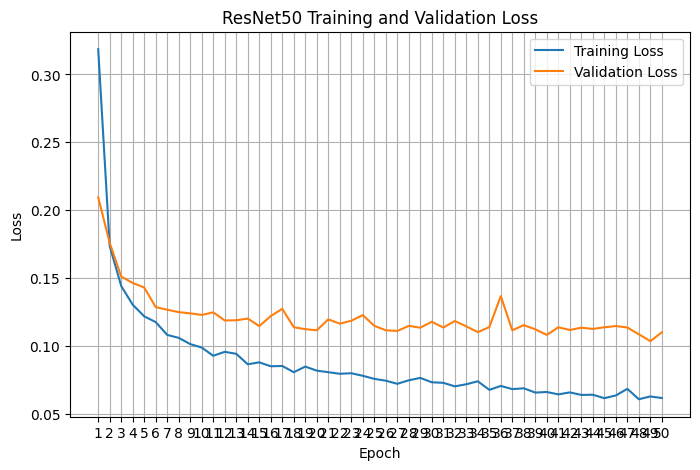

In [28]:
# Create the epoch numbers
epochs = range(1, len(history["train_loss"]) + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_loss"], label="Training Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig(
    "resnet50_frozen_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()




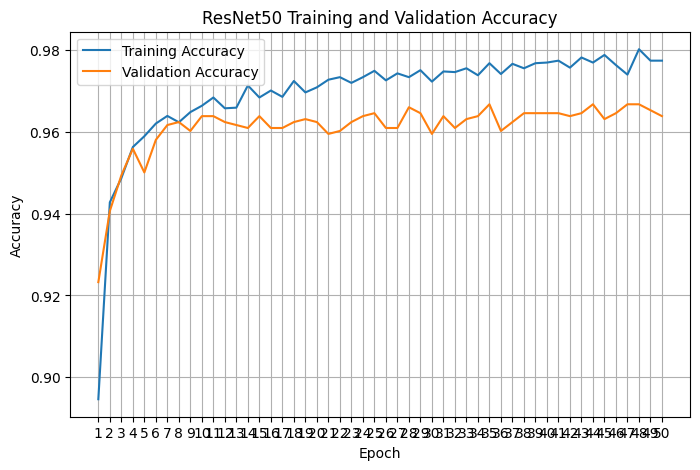

In [29]:
# Create the epoch numbers
epochs = range(1, len(history["train_accuracy"]) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(epochs, history["train_accuracy"], label="Training Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig(
    "resnet50_frozen_training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [30]:
# Rebuild the ResNet50 architecture
resnet50 = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Replace the ImageNet classifier with our 3-class classifier
resnet50.fc = nn.Linear(
    resnet50.fc.in_features,
    NUM_CLASSES
)

# Load the best validation-loss checkpoint
best_model_path = "/kaggle/working/best_resnet50_frozen.pth"
resnet50.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

# Move the model to the selected device
resnet50 = resnet50.to(device)

# Switch to evaluation mode
resnet50.eval()

print("Best ResNet50 checkpoint loaded successfully.")

Best ResNet50 checkpoint loaded successfully.


In [31]:
# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            # Probabilities
            probabilities = torch.softmax(outputs, dim=1)

            # Predictions
            predictions = outputs.argmax(dim=1)

            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

            # Accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    # Average loss
    loss = total_loss / total

    # Accuracy
    accuracy = correct / total

    # Convert lists to NumPy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    return (
        loss,
        accuracy,
        total,
        all_predictions,
        all_labels,
        all_probabilities
    )

In [32]:
val_loss, val_accuracy, total, all_predictions, all_labels, all_probabilities = evaluate_model(
    resnet50,
    val_loader,
    criterion,
    device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Samples: {total}")

print("Probability shape:", all_probabilities.shape)
print("Labels shape:", all_labels.shape)

Validation Loss: 0.1036
Validation Accuracy: 0.9652
Validation Accuracy: 96.52%
Validation Samples: 1381
Probability shape: (1381, 3)
Labels shape: (1381,)


In [33]:
# =========================
# Classification Report
# =========================

report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      Normal     0.9533    0.9571    0.9552       490
    COVID-19     0.9947    0.9740    0.9842       192
   Pneumonia     0.9658    0.9685    0.9671       699

    accuracy                         0.9652      1381
   macro avg     0.9712    0.9665    0.9688      1381
weighted avg     0.9653    0.9652    0.9653      1381



In [34]:
# =========================
# Specificity for Each Class
# =========================
cm = confusion_matrix(all_labels, all_predictions)

specificity = []

for i in range(len(CLASS_NAMES)):
    true_negative = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
    false_positive = np.sum(cm[:, i]) - cm[i, i]

    spec = true_negative / (true_negative + false_positive)
    specificity.append(spec)

for class_name, spec in zip(CLASS_NAMES, specificity):
    print(f"{class_name}: {spec:.4f} ({spec * 100:.2f}%)")

Normal: 0.9742 (97.42%)
COVID-19: 0.9992 (99.92%)
Pneumonia: 0.9648 (96.48%)


In [35]:
# ============================================================
# ROC Curve and AUC
# ============================================================

# Binarize the true labels
y_true = label_binarize(
    all_labels,
    classes=[0, 1, 2]
)

# Calculate ROC curve for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        y_true[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# Macro-average ROC-AUC
macro_auc = roc_auc_score(
    all_labels,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)

# Print AUC values
for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name} ROC-AUC: "
        f"{roc_auc[i]:.4f}"
    )

print(f"Macro-average ROC-AUC: {macro_auc:.4f}")

Normal ROC-AUC: 0.9954
COVID-19 ROC-AUC: 0.9979
Pneumonia ROC-AUC: 0.9956
Macro-average ROC-AUC: 0.9963


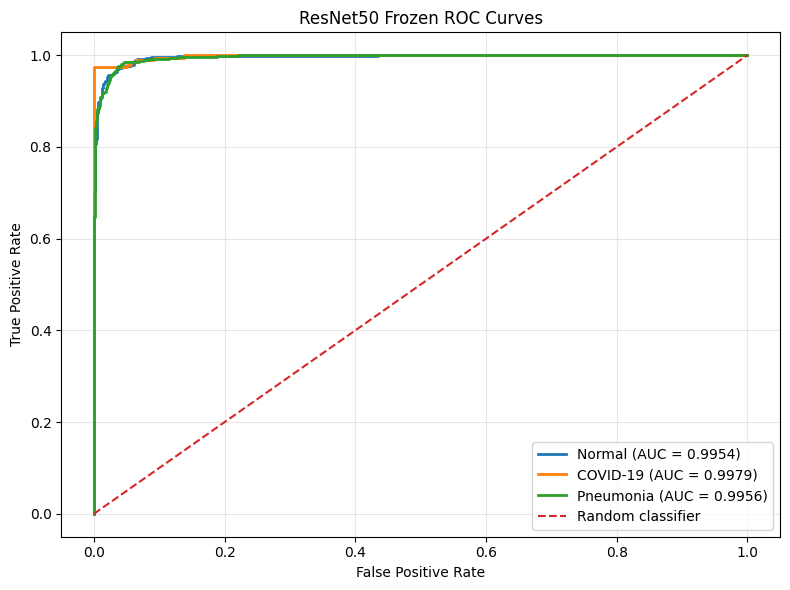

In [36]:
# ============================================================
# Plot ROC Curves
# ============================================================

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(CLASS_NAMES):

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc[i]:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 Frozen ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_frozen_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:

print("Current working directory:")
print(os.getcwd())

print("\nCheckpoint path:")
print(os.path.abspath(best_model_path))
print(os.listdir("/kaggle/working"))

Current working directory:
/kaggle/working

Checkpoint path:
/kaggle/working/best_resnet50_frozen.pth
['resnet50_frozen_roc_curve.png', 'resnet50_frozen_training_accuracy.png', 'resnet50_frozen_training_loss.png', '.virtual_documents', 'best_resnet50_frozen.pth']
